# Anomalib 03_EfficientAD 실행

### 경로 : examples/notebooks/03_models/fastflow.ipynb

### 데이터셋 설정

In [1]:
from pathlib import Path

# NOTE: Provide the path to the dataset root directory.
#   If the datasets is not downloaded, it will be downloaded
#   to this directory.
dataset_root = Path.cwd()/ "bolt"

### Imports

In [2]:
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt
from PIL import Image

from anomalib.engine import Engine
from anomalib.models import EfficientAd
from anomalib.utils.post_processing import superimpose_anomaly_map

from anomalib.data import Folder, FolderDataset

W0601 22:58:24.667000 8048 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


### 데이터 모듈

In [3]:
folder_datamodule = Folder(
    name="bolt",
    root=dataset_root,
    normal_dir="train/good", # 학습용 정상 이미지
    abnormal_dir="test/ng", # 테스트용 비정상 이미지
    test_split_ratio = 0.0,
    # val_split_ratio = 0.2,
    val_split_ratio = 0.0, # threshold 보정용 val 추가
    seed = 42,
    train_batch_size = 1,
    num_workers = 0
)
folder_datamodule.setup()


### EfficientAD Model

In [4]:
EfficientAd??

Init signature:
EfficientAd(
    imagenet_dir: pathlib.Path | str = './datasets/imagenette',
    teacher_out_channels: int = 384,
    model_size: anomalib.models.image.efficient_ad.torch_model.EfficientAdModelSize | str = <EfficientAdModelSize.S: 'small'>,
    lr: float = 0.0001,
    weight_decay: float = 1e-05,
    padding: bool = False,
    pad_maps: bool = True,
    pre_processor: anomalib.pre_processing.pre_processor.PreProcessor | bool = True,
    post_processor: anomalib.post_processing.post_processor.PostProcessor | bool = True,
    evaluator: anomalib.metrics.evaluator.Evaluator | bool = True,
    visualizer: anomalib.visualization.base.Visualizer | bool = True,
) -> None
Source:        
class EfficientAd(AnomalibModule):
    """PL Lightning Module for the EfficientAd algorithm.

    The EfficientAd model uses a student-teacher architecture with a pretrained
    EfficientNet backbone for fast and accurate anomaly detection.

    Args:
        imagenet_dir (Path | str): Director

### 전처리 설정

- CLAHE 적용

In [5]:
import cv2
import numpy as np
from PIL import Image
from anomalib.pre_processing import PreProcessor
from torchvision.transforms.v2 import Compose, Resize

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img, *args):
        if isinstance(img, Image.Image):   # ← PIL 이미지일 때만 CLAHE 적용
            clahe = cv2.createCLAHE(
                clipLimit=self.clip_limit,
                tileGridSize=self.tile_grid_size
            )
            img_array = np.array(img)
            lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            img_array = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            result = Image.fromarray(img_array)
        else:
            result = img               # ← 텐서면 그대로 통과

        if args:
            return (result,) + args
        return result

pre_processor = PreProcessor(
    transform=Compose([
        Resize((256, 256)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8))
    ])
)

### 모델 파라미터 설정

In [6]:
# 1. 기본 파라미터로 설정 함

model = EfficientAd(
    imagenet_dir = './datasets/imagenette',
    teacher_out_channels = 384,
    model_size = 'small',
    lr = 0.0001,
    weight_decay = 1e-05,
    padding = False,
    pad_maps = True,
    pre_processor = pre_processor,
    post_processor = True,
    evaluator = True,
    visualizer = True,
)

c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.


### 콜백(Callbacks)

- 모델을 제대로 학습시키기 위해서는 가중치 저장, 조기 종료(Early Stopping), 이상 점수 정규화, 입력/출력 이미지 시각화와 같은 추가적인 “비핵심” 로직도 함께 넣어야 합니다. 이러한 기능을 구현하기 위해 콜백(Callbacks)을 사용합니다.

In [7]:
# ModelCheckpoint() → 학습 중 모델 가중치 자동 저장
# EarlyStopping() → 성능 향상이 없으면 자동 종료

callbacks = [
    ModelCheckpoint(
        mode="min",
        monitor="train_loss",
        save_last=True,
    ),
    EarlyStopping(
        monitor="train_loss",
        mode="min",
        patience=5,
    ),
]

### Engine 객체 생성

- 이제 데이터 모듈(datamodule), 모델(model), 옵티마이저(optimizer), 그리고 콜백(callbacks) 설정이 완료되었으므로 모델을 학습시킬 수 있습니다.

- 모델 학습에 필요한 마지막 구성 요소는 Engine 객체입니다.
- 이 객체는 학습(train), 테스트(test), 예측(predict) 파이프라인을 관리합니다.

- 이제 모델 학습을 위해 Engine 객체를 생성해 보겠습니다.

In [8]:
engine = Engine(
    callbacks=callbacks,
    accelerator="gpu",  # \<"cpu", "gpu", "tpu", "ipu", "hpu", "auto">,
    devices=1,
    logger=True,
    max_epochs = 50,
    enable_progress_bar = False # Progress bar 비활성화 (오류 해결)
)

### 모델 학습

In [9]:
engine.fit(datamodule=folder_datamodule, model=model)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor     │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor    │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator        │      0 │ train │     0 │
│ 3 │ model          │ EfficientAdModel │  8.1 M │ train │     0 │
└───┴────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.1 M                                                                                                
Total estimated model params size (MB): 32                                                                         
Modules in train mode: 48                                                                                          
Modules in eval mode: 7                                                                                            
Total FLOPs: 0

c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 7 module(s) in eval mode at the start of training. 

### 테스트(Testing)

- 이제 모델 학습이 완료되었으므로, 테스트 세트(test set)에서 모델의 전체 성능을 확인하기 위해 테스트를 진행할 수 있습니다.

- 또한 callbacks에서 VisualizerCallback을 설정했기 때문에, 테스트 이미지의 출력 결과도 파일로 저장하게 됩니다.

In [10]:
# normal_test_dir 제거로 test set에 good 이미지가 없어
# engine.test()의 AUROC 계산이 불가하므로 주석 처리
# engine.test(datamodule=folder_datamodule, model=model)

### 추론(Inference)

- 이제 학습된 모델이 있으므로, 단일 이미지 또는 이미지 폴더에 대해 모델 추론을 수행할 수 있습니다.

- 이미지에 대해 추론을 실행하려면, engine의 predict 메서드에 해당 경로(path)를 전달하면 됩니다.

In [11]:
data_path = sorted((dataset_root / "test" / "ng").glob("*.jpg"))[0]
predictions = engine.predict(model=model, data_path=data_path)
prediction = predictions[0]  # Get the first and only prediction

ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


In [12]:
print(
    f"Image Shape: {prediction.image.shape},\n"
    f"Anomaly Map Shape: {prediction.anomaly_map.shape}, \n"
    f"Predicted Mask Shape: {prediction.pred_mask.shape}",
)

Image Shape: torch.Size([1, 3, 256, 256]),
Anomaly Map Shape: torch.Size([1, 256, 256]), 
Predicted Mask Shape: torch.Size([1, 256, 256])


### Threshold 산출 — train/good Percentile 95

test 데이터를 전혀 사용하지 않고, 정상 이미지 점수 분포에서만 threshold를 결정합니다.

In [13]:
# train/good 전체 예측
train_preds = engine.predict(model=model, data_path=dataset_root / "train" / "good")
train_scores = [float(p.pred_score[0].item()) for p in train_preds]

PERCENTILE = 99
threshold_value = np.percentile(train_scores, PERCENTILE)
print(f"Train/good  min={min(train_scores):.4f}  max={max(train_scores):.4f}  mean={np.mean(train_scores):.4f}")
print(f"Threshold (p{PERCENTILE}): {threshold_value:.4f}")

ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Train/good  min=0.0953  max=1.0000  mean=0.1226
Threshold (p99): 0.3125


### Confusion Matrix 시각화

- Confusion Matrix 추가

ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Tra

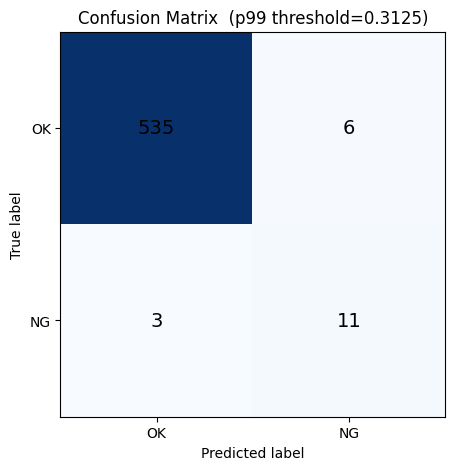

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_pred_labels = []
all_gt_labels = []

import pandas as pd
good_paths = sorted((dataset_root / "test" / "good").glob("*.jpg"))
ng_paths   = sorted((dataset_root / "test" / "ng").glob("*.jpg"))
test_samples = pd.DataFrame(
    [{"image_path": str(p), "label_index": 0} for p in good_paths]
  + [{"image_path": str(p), "label_index": 1} for p in ng_paths]
)

for _, row in test_samples.iterrows():
    img_path = row["image_path"]
    gt_label = 0 if row["label_index"] == 0 else 1
    preds = engine.predict(model=model, data_path=img_path)
    for pred in preds:
        score = float(pred.pred_score[0].item())
        all_pred_labels.append(1 if score > threshold_value else 0)
        all_gt_labels.append(gt_label)

cm = confusion_matrix(all_gt_labels, all_pred_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["OK", "NG"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False, text_kw={"fontsize": 14, "color": "black"})
plt.title(f"Confusion Matrix  (p{PERCENTILE} threshold={threshold_value:.4f})")
plt.show()


### 평가 지표 추가

In [15]:
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, roc_auc_score,
    average_precision_score,
    accuracy_score
)

all_pred_labels = []
all_gt_labels   = []
all_pred_scores = []

import pandas as pd
good_paths = sorted((dataset_root / "test" / "good").glob("*.jpg"))
ng_paths   = sorted((dataset_root / "test" / "ng").glob("*.jpg"))
test_samples = pd.DataFrame(
    [{"image_path": str(p), "label_index": 0} for p in good_paths]
  + [{"image_path": str(p), "label_index": 1} for p in ng_paths]
)

for _, row in test_samples.iterrows():
    img_path = row["image_path"]
    gt_label = 0 if row["label_index"] == 0 else 1
    preds = engine.predict(model=model, data_path=img_path)
    for pred in preds:
        score = float(pred.pred_score[0].item())
        all_pred_labels.append(1 if score > threshold_value else 0)
        all_gt_labels.append(gt_label)
        all_pred_scores.append(score)

accuracy  = accuracy_score(all_gt_labels, all_pred_labels)
precision = precision_score(all_gt_labels, all_pred_labels, zero_division=0)
recall    = recall_score(all_gt_labels, all_pred_labels, zero_division=0)
f1        = f1_score(all_gt_labels, all_pred_labels, zero_division=0)
auroc     = roc_auc_score(all_gt_labels, all_pred_scores)
pr_auc    = average_precision_score(all_gt_labels, all_pred_scores)

print(f"Accuracy  : {accuracy:.4f}")
print(f"AUROC     : {auroc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\KDS21\anaconda3\envs\dl_new\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Tra

Accuracy  : 0.9838
AUROC     : 0.9667
PR-AUC    : 0.7446
Precision : 0.6471
Recall    : 0.7857
F1 Score  : 0.7097


### K - Fold 교차 검증 추가

In [16]:
# from sklearn.model_selection import KFold
# import numpy as np

# ng_images = sorted(Path(dataset_root / "NG").glob("*.jpg"))
# ok_images = sorted(Path(dataset_root / "OK").glob("*.jpg"))

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# fold_results = []

# for fold, (_, test_ng_idx) in enumerate(kf.split(ng_images)):
#     test_ng = [ng_images[i] for i in test_ng_idx]
    
#     pred_labels, gt_labels, pred_scores = [], [], []

#     # OK 이미지 예측
#     ok_preds = engine.predict(model=model, data_path=dataset_root / "OK")
#     for pred in ok_preds:
#         pred_labels.append(int(pred.pred_label[0].item()))
#         gt_labels.append(0)
#         pred_scores.append(float(pred.pred_score[0].item()))

#     # 이번 fold의 NG 이미지 예측
#     for ng_path in test_ng:
#         preds = engine.predict(model=model, data_path=ng_path)
#         for pred in preds:
#             pred_labels.append(int(pred.pred_label[0].item()))
#             gt_labels.append(1)
#             pred_scores.append(float(pred.pred_score[0].item()))

#     auroc = roc_auc_score(gt_labels, pred_scores)
#     f1    = f1_score(gt_labels, pred_labels, zero_division=0)
#     fold_results.append({"fold": fold+1, "auroc": auroc, "f1": f1})
#     print(f"Fold {fold+1}: AUROC={auroc:.4f}, F1={f1:.4f} (NG {len(test_ng)}장)")

# print(f"\n평균 AUROC : {np.mean([r['auroc'] for r in fold_results]):.4f}")
# print(f"평균 F1    : {np.mean([r['f1'] for r in fold_results]):.4f}")
# print(f"AUROC 표준편차: {np.std([r['auroc'] for r in fold_results]):.4f}")

### 시각화(Visualization)

- 예측 결과를 올바르게 시각화하기 위해서는 몇 가지 후처리(post-processing) 작업을 수행해야 합니다.

- 먼저 입력 이미지를 표시해 보겠습니다. 이를 위해 prediction 딕셔너리의 image_path key를 사용하여 해당 경로에서 이미지를 읽어옵니다.

- 참고로 prediction 딕셔너리 안에는 이미 image 데이터가 포함되어 있습니다. 하지만 이 이미지는 픽셀 값이 0~1 사이로 정규화(normalized)된 상태입니다.

- 따라서 입력 이미지를 시각화할 때는 정규화된 이미지 대신 원본 이미지를 사용하겠습니다.

In [17]:
image_path = prediction.image_path[0]
image_size = prediction.image.shape[-2:]
image = np.array(Image.open(image_path).resize(image_size))

### 예측 결과의 첫 번째 출력은 anomaly map(이상 맵)입니다.

- 위에서 볼 수 있듯이, 이것 역시 torch tensor 형태이며 크기는 torch.Size([1, 1, 256, 256]) 입니다.

- 따라서 시각화를 위해서는:

- 이를 NumPy 형태로 변환하고
- 불필요한 차원(dimensions)을 제거(squeeze)

- 하여 256 × 256 형태의 출력으로 만들어야 합니다.

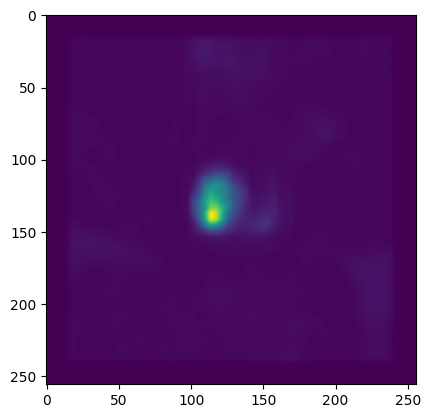

In [18]:
anomaly_map = prediction.anomaly_map[0]
anomaly_map = anomaly_map.cpu().numpy().squeeze()
plt.imshow(anomaly_map)

### 원본 이미지 위에 anomaly map(이상 맵)을 겹쳐(superimpose, overlay) 표시하여 heat map을 만들 수 있습니다.

### Anomalib에는 이를 수행하기 위한 내장 함수(built-in function)가 제공됩니다.

### 이제 이를 사용해 보겠습니다.

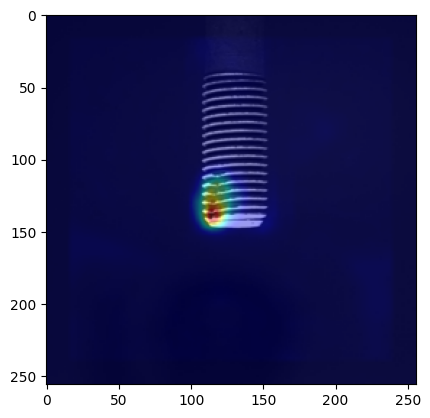

In [19]:
heat_map = superimpose_anomaly_map(anomaly_map=anomaly_map, image=image, normalize=True)
plt.imshow(heat_map)

### prediction 안에는 모델이 예측한 점수와 라벨 정보도 들어 있다

In [20]:
pred_score = prediction.pred_score[0]
pred_labels = prediction.pred_label[0]
print(pred_score, pred_labels)

tensor([0.6866]) tensor(True)


### 예측 결과의 마지막 부분은 모델이 예측한 마스크(mask)입니다.

- 이 마스크는 boolean 형태의 마스크이며,

- 비정상(abnormal) 픽셀은 True
- 정상(normal) 픽셀은 False

- 값으로 나타냅니다.

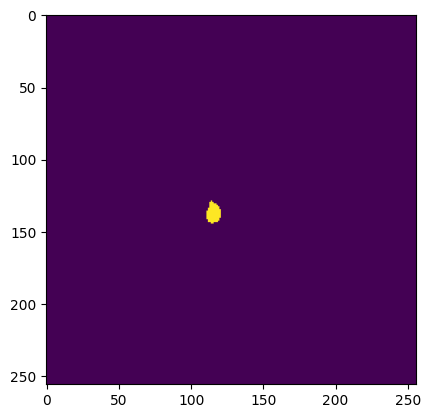

In [21]:
pred_masks = prediction.pred_mask[0].squeeze().cpu().numpy()
plt.imshow(pred_masks)